# 실습 5-2 : SHAP Value

#### **<실습 내용>**

1. SHAP - 회귀 모델 (Regression)
- TreeExplainer를 사용한 SHAP 분석
- Summary Plot / Force Plot / Dependence Plot

3. SHAP - 분류 모델 (Classification)
- TreeExplainer를 사용한 SHAP 분석
- Summary Plot / Force Plot / Dependence Plot

## 분석 준비

### 주요 라이브러리 호출

In [1]:
!pip install shap

   ---------------------------------------- 0.0/547.2 kB ? eta -:--:--
   ---------------------------------------- 547.2/547.2 kB 9.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------------------- -------- 2.1/2.7 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 8.2 MB/s  0:00:00
   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
   ---- ----------------------------------- 3.4/28.1 MB 16.8 MB/s eta 0:00:02
   --------- ------------------------------ 6.6/28.1 MB 16.1 MB/s eta 0:00:02
   ----------- ---------------------------- 7.9/28.1 MB 12.5 MB/s eta 0:00:02
   -------------- ------------------------- 10.5/28.1 MB 13.6 MB/s eta 0:00:02
   ------------------- -------------------- 13.9/28.1 MB 13.2 MB/s eta 0:00:02
   ------------------------ --------------- 17.3/28.1 MB 13.8 MB/s eta 0:00:01
   --------------------------- ------------ 19.7/28.1 MB 13.4 MB/s eta 0:00:01
   ----------

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, f1_score
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

import shap

c:\Users\Admin\Miniconda3\envs\day4\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## 1) SHAP - 회귀 모델

In [3]:
# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

### 1-1) 데이터 및 모델 준비

In [6]:
Regression = pd.read_csv("dataset/day5-2_reg_data.csv")
Regression

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X50,X51,X52,X53,X54,X55,X56,X57,X58,y
0,0.40420,0.39615,0.34470,0.39535,0.44180,0.38830,0.36245,0.34480,0.32475,0.38020,...,0.39200,0.34985,0.37980,0.42355,0.38990,0.40890,0.41720,0.37765,0.36190,48.272178
1,0.47115,0.35280,0.29120,0.30190,0.54875,0.40430,0.42125,0.32620,0.35280,0.43115,...,0.32080,0.35185,0.35570,0.38400,0.44375,0.25945,0.55030,0.43205,0.31395,49.767621
2,0.31185,0.35220,0.41940,0.38370,0.30015,0.32555,0.39790,0.44730,0.55625,0.60885,...,0.36105,0.36230,0.30455,0.26945,0.49770,0.37425,0.27800,0.41980,0.37620,45.512356
3,0.43900,0.38300,0.38830,0.33920,0.40740,0.40650,0.45455,0.40565,0.41915,0.33565,...,0.33715,0.46605,0.45040,0.37150,0.37625,0.28595,0.45195,0.40570,0.39885,55.646432
4,0.38005,0.42835,0.53105,0.39145,0.31755,0.40365,0.33230,0.48530,0.44295,0.37615,...,0.43555,0.30330,0.26910,0.35155,0.42230,0.43660,0.35875,0.43605,0.46260,47.703096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,0.40675,0.37110,0.29385,0.37125,0.43345,0.32380,0.40365,0.32200,0.35655,0.50940,...,0.31965,0.32385,0.37480,0.37240,0.46065,0.33660,0.40075,0.37875,0.30040,44.683854
237,0.37940,0.36660,0.39205,0.42100,0.37860,0.42690,0.39580,0.39240,0.39080,0.35705,...,0.43260,0.40485,0.36410,0.45070,0.37270,0.45270,0.36685,0.39055,0.40395,47.907255
238,0.35150,0.35285,0.24365,0.40190,0.50055,0.37125,0.36820,0.28830,0.34130,0.48590,...,0.38300,0.38705,0.41305,0.40750,0.39510,0.40895,0.40825,0.35865,0.30240,45.900853
239,0.30580,0.46180,0.50870,0.43220,0.38695,0.43260,0.24155,0.45805,0.38565,0.29875,...,0.51305,0.36490,0.35580,0.36160,0.31170,0.53040,0.36960,0.38475,0.49090,51.418961


In [7]:
X_reg = Regression.drop(["y"], axis=1) # 입력변수
Y_reg = Regression["y"] # 출력변수

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(X_reg, Y_reg, test_size=0.2, random_state=42) # 학습/테스트 데이터 분할

In [8]:
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=0) # RandomForest로 모델 학습
rf_reg.fit(X_train_reg, Y_train_reg)
Y_pred_reg = rf_reg.predict(X_test_reg)
get_regscore(Y_test_reg, Y_pred_reg)

MSE       : 6.592
RMSE      : 2.568
MAE       : 1.991
R-squared : 0.558


### 2-2) SHAP 분석

In [9]:
# rf_reg 모델을 해석하기 위한 SHAP 설명자 생성
explainer_reg = shap.TreeExplainer(rf_reg)

# 학습 데이터(X_train_reg)에 대한 SHAP value 계산
# 각 feature가 예측값에 기여하는 정도를 나타냄
shap_values_reg = explainer_reg.shap_values(X_train_reg)

#### Summary Plot (Bar)
- 막대가 길수록 예측에 영향을 많이 주는 변수라는 뜻임

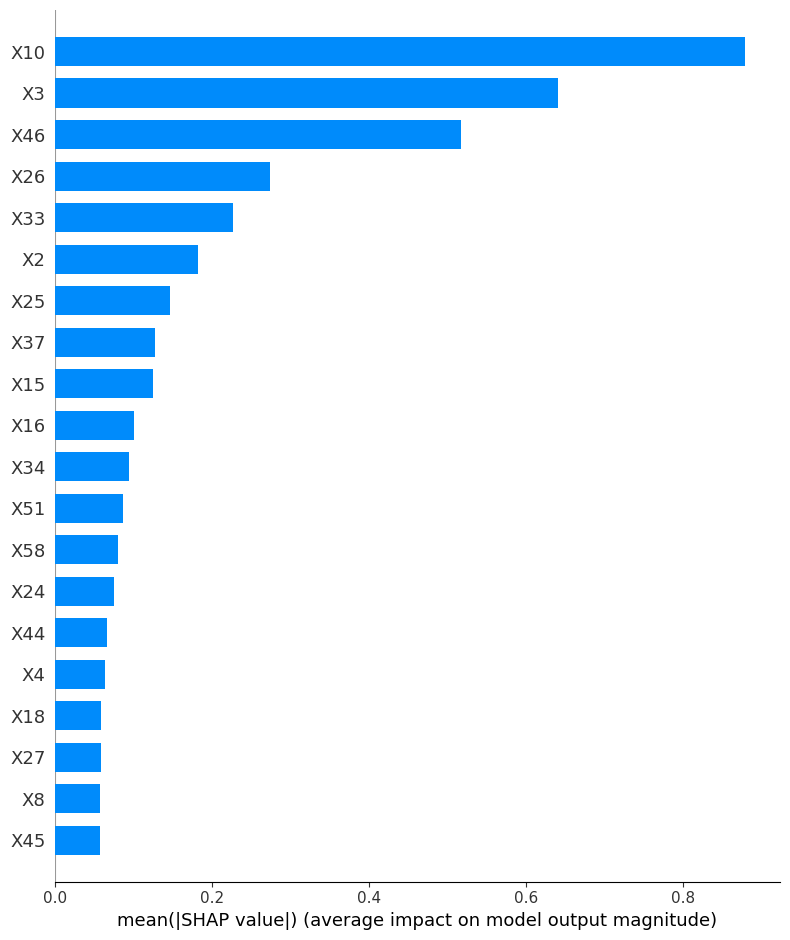

In [10]:
shap.summary_plot(shap_values_reg, X_train_reg, plot_type='bar')

#### Summary Plot (Scatter)
- 오른쪽에 점이 몰려있으면 예측값을 올리는 변수, 왼쪽에 몰려있으면 예측값을 낮추는 변수임

> - 빨간색: 높은 변수 값
> - 파란색: 낮은 변수 값

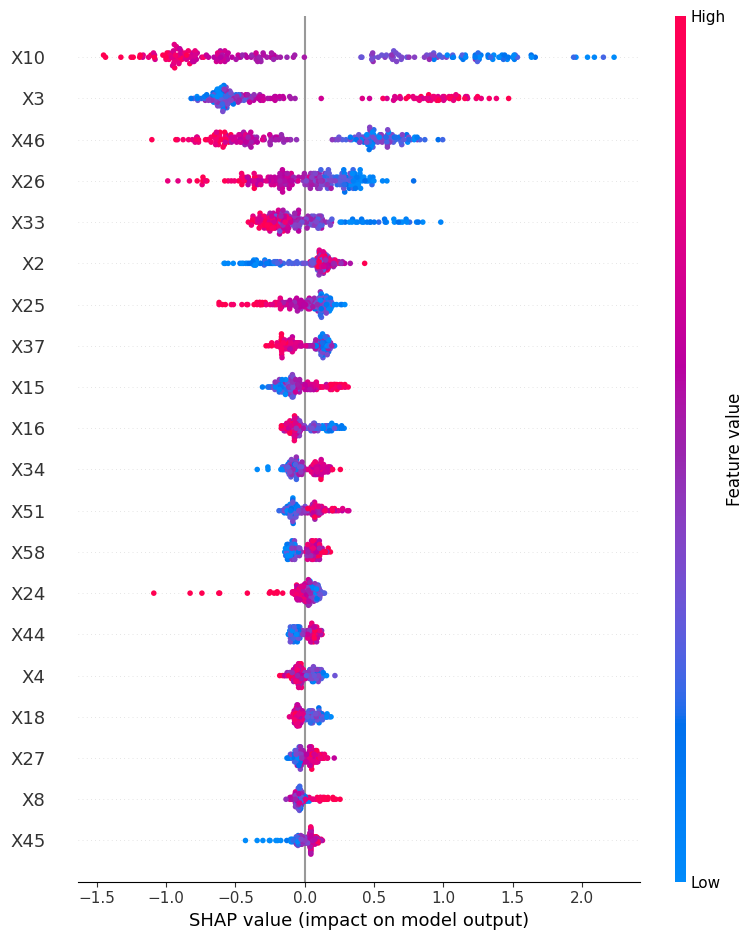

In [11]:
shap.summary_plot(shap_values_reg, X_train_reg)

#### Force Plot (개별 데이터)
- 데이터 하나를 뽑아서 어떤 변수가 예측값을 올렸고 내렸는지 화살표로 보여주는 그래프임

In [12]:
base_value_reg = explainer_reg.expected_value
print(base_value_reg)

[49.74460342]


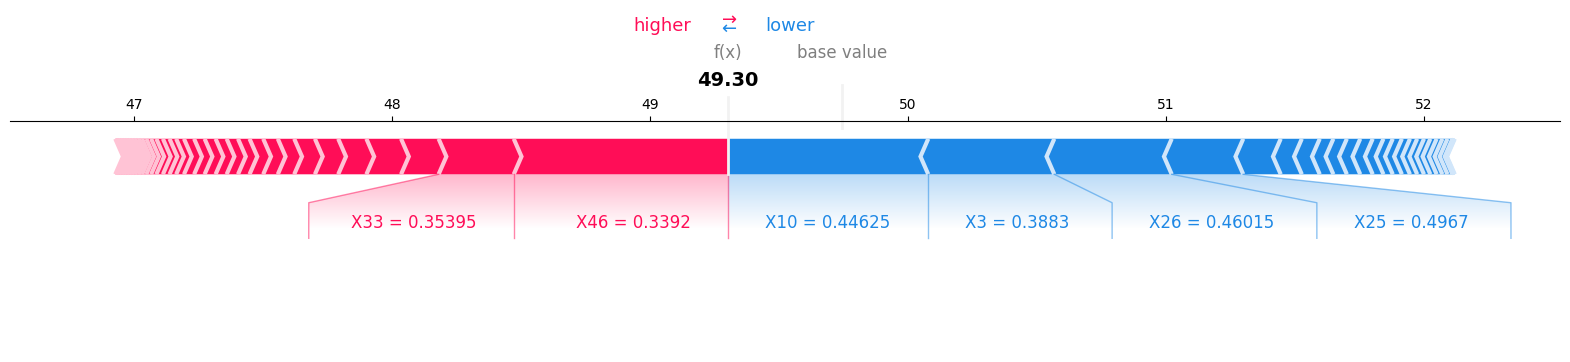

In [13]:
# 첫 번째 데이터(index 0)의 예측 결과를 force plot으로 시각화
# expected_value: 전체 데이터의 평균 예측값 (기준선)
# shap_values_reg[0]: 이 데이터의 각 feature별 SHAP value 
# X_train_reg.iloc[0]: 실제 feature 값들 (그래프에 표시용)

shap.force_plot(
    explainer_reg.expected_value,
    shap_values_reg[0],
    X_train_reg.iloc[0],
    matplotlib=True
)

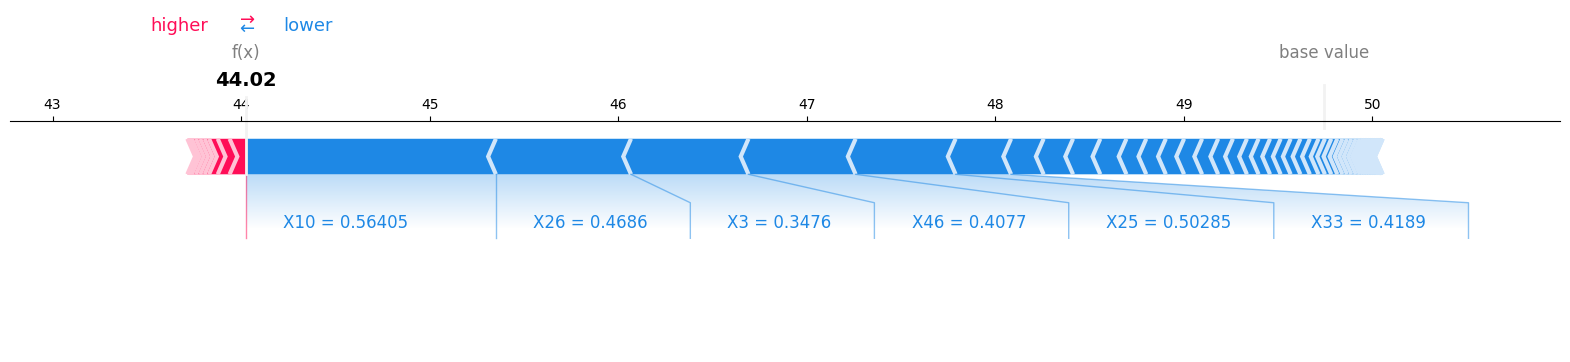

In [29]:
# 첫 번째 데이터(index 0)의 예측 결과를 force plot으로 시각화
# expected_value: 전체 데이터의 평균 예측값 (기준선)
# shap_values_reg[0]: 이 데이터의 각 feature별 SHAP value 
# X_train_reg.iloc[0]: 실제 feature 값들 (그래프에 표시용)

shap.force_plot(
    explainer_reg.expected_value,
    shap_values_reg[2],
    X_train_reg.iloc[2],
    matplotlib=True
)

In [31]:
X_train_reg

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X49,X50,X51,X52,X53,X54,X55,X56,X57,X58
115,0.25545,0.38710,0.38830,0.38685,0.49260,0.43495,0.29065,0.41460,0.47565,0.44625,...,0.45235,0.47175,0.46140,0.40555,0.29280,0.32820,0.44385,0.41560,0.39970,0.42275
205,0.43825,0.41800,0.46050,0.39160,0.27385,0.40365,0.48270,0.44160,0.41000,0.25925,...,0.38430,0.35485,0.48170,0.48880,0.41125,0.33690,0.33545,0.35560,0.38880,0.44110
216,0.30720,0.36490,0.34760,0.37825,0.46060,0.36665,0.32550,0.38430,0.46605,0.56405,...,0.38470,0.40015,0.34555,0.31380,0.30390,0.45045,0.40905,0.38400,0.40975,0.35475
132,0.50870,0.40035,0.46445,0.34075,0.30735,0.39090,0.51755,0.46805,0.45725,0.32895,...,0.35655,0.28915,0.39040,0.36430,0.39970,0.46015,0.26120,0.41385,0.45315,0.41265
84,0.45335,0.44715,0.39735,0.40660,0.34905,0.37935,0.42720,0.38255,0.32350,0.27745,...,0.37175,0.34605,0.39105,0.45755,0.44570,0.36515,0.37280,0.38240,0.37335,0.39520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.45220,0.29925,0.26035,0.34970,0.40675,0.34970,0.52445,0.31900,0.40355,0.49855,...,0.36465,0.28060,0.41875,0.40720,0.41485,0.46875,0.26500,0.40870,0.39200,0.28460
14,0.35020,0.25880,0.15225,0.37575,0.48410,0.32805,0.47105,0.25070,0.40235,0.60305,...,0.38205,0.31385,0.47060,0.45895,0.38625,0.43880,0.31910,0.38575,0.33970,0.23715
92,0.38855,0.47620,0.56815,0.42065,0.23990,0.40090,0.37600,0.51770,0.45250,0.28045,...,0.35820,0.41365,0.37725,0.37110,0.36965,0.37200,0.43555,0.30775,0.41665,0.50080
179,0.46345,0.37015,0.48510,0.30250,0.32840,0.37200,0.46570,0.48690,0.51965,0.46570,...,0.35060,0.30505,0.33010,0.26880,0.30190,0.51750,0.24275,0.42365,0.48265,0.40340


In [32]:
X_train_reg.iloc[0]

X1     0.25545
X2     0.38710
X3     0.38830
X4     0.38685
X5     0.49260
X6     0.43495
X7     0.29065
X8     0.41460
X9     0.47565
X10    0.44625
X11    0.43440
X12    0.35210
X13    0.40675
X14    0.27300
X15    0.41205
X16    0.37505
X17    0.43730
X18    0.35145
X19    0.33115
X20    0.32045
X21    0.36350
X22    0.39110
X23    0.46230
X24    0.36490
X25    0.49670
X26    0.46015
X27    0.36750
X28    0.45070
X29    0.53510
X30    0.40785
X31    0.36835
X32    0.42290
X33    0.35395
X34    0.39705
X35    0.28345
X36    0.45475
X37    0.35360
X38    0.29585
X39    0.33565
X40    0.46370
X41    0.35170
X42    0.37275
X43    0.48615
X44    0.44525
X45    0.38115
X46    0.33920
X47    0.22300
X48    0.42915
X49    0.45235
X50    0.47175
X51    0.46140
X52    0.40555
X53    0.29280
X54    0.32820
X55    0.44385
X56    0.41560
X57    0.39970
X58    0.42275
Name: 115, dtype: float64

#### Dependence Plot
- 변수 값이 변할 때 SHAP 값(영향력)이 같이 어떻게 움직이는지 보여주는 그래프임

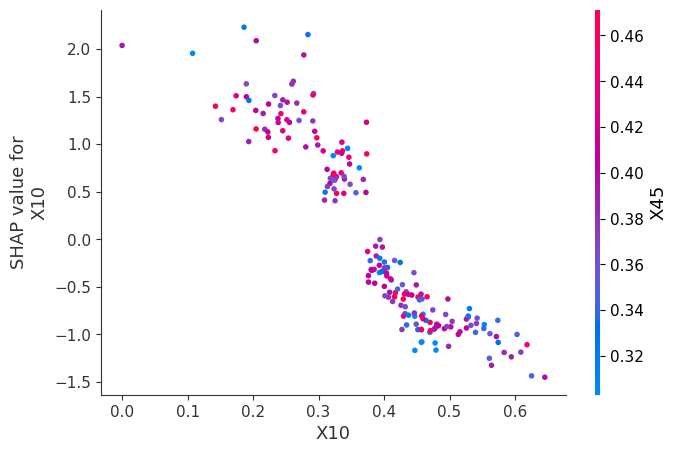

In [33]:
# "X10" feature 값에 따라 SHAP value가 어떻게 변하는지 시각화
# x축: X10의 실제 값, y축: X10의 SHAP value (예측에 미친 영향)
# 자동으로 X10과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X10",
    shap_values_reg,
    X_train_reg
)

---

## 3) SHAP - 분류 모델

In [34]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

### 3-1) 데이터 및 모델 준비

In [35]:
Classification = pd.read_csv("dataset/day5-2_cls_data.csv")
Classification

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X466,X467,X468,X469,X470,X471,X472,X473,X474,Y
0,0.457896,0.530189,0.276976,0.359864,0.193059,0.322190,0.706897,0.553781,0.653894,0.375204,...,0.246376,0.711806,0.008532,0.013672,0.008467,0.402240,0.238811,0.274876,0.210238,-1
1,0.607100,0.341478,0.518992,0.395300,0.042071,0.469654,0.750000,0.542031,0.447466,0.189233,...,0.523785,0.760417,0.030930,0.033203,0.029759,0.210356,0.309339,0.328358,0.439175,-1
2,0.360781,0.369653,0.341039,0.021697,0.181737,0.528684,0.491379,0.516722,0.300371,0.376835,...,0.185769,0.659722,0.005333,0.003906,0.005311,0.381877,0.208171,0.208955,0.155761,-1
3,0.460910,0.413500,0.535685,0.302794,0.242326,0.408966,0.646552,0.561615,0.415328,0.313214,...,0.246376,0.000000,1.000000,1.000000,1.000000,0.381877,0.208171,0.208955,0.155761,-1
4,0.263068,0.279821,0.535685,0.302794,0.242326,0.408966,0.646552,0.638747,0.660074,0.520392,...,0.110711,0.517361,0.023677,0.022461,0.023447,0.608414,0.212062,0.268657,0.092827,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,0.360022,0.396033,0.382803,0.070771,0.143308,0.920884,0.586207,0.636336,0.337454,0.432300,...,0.000000,0.597222,0.016212,0.013672,0.015997,0.045307,0.147860,0.171642,0.000000,1
250,0.508628,0.437628,0.192378,0.061866,0.168425,0.481919,0.715517,0.270563,0.407911,0.336052,...,0.132582,0.975694,0.017065,0.015625,0.016114,0.543689,0.227626,0.320896,0.111165,1
251,0.275930,0.364365,0.302236,0.376615,0.485135,0.627270,0.594828,0.435673,0.420272,0.367047,...,0.246376,0.586806,0.008532,0.015625,0.008613,0.343042,0.151751,0.164179,0.143012,1
252,0.785179,0.271804,0.400189,0.457851,0.229526,0.244320,0.396552,0.875565,0.110012,0.337684,...,0.221768,0.767361,0.024317,0.019531,0.023461,0.509709,0.398833,0.440299,0.185945,1


In [36]:
X_cls = Classification.drop(["Y"], axis=1) # 입력변수
Y_cls = Classification["Y"] # 출력변수

X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls, test_size=0.2, random_state=123, stratify=Y_cls)

rf_cls = RandomForestClassifier(n_estimators=100, random_state=0)
rf_cls.fit(X_train_cls, Y_train_cls)
Y_pred_cls = rf_cls.predict(X_test_cls)
get_classscore(Y_test_cls, Y_pred_cls)

Accuracy  : 0.863
Precision : 0.938
Recall    : 0.714
F1-score  : 0.811

혼동행렬
[[29  1]
 [ 6 15]]


### 3-2) SHAP 분석

In [37]:
explainer_cls = shap.TreeExplainer(rf_cls)
shap_values_cls = explainer_cls.shap_values(X_train_cls)

#### Summary Plot (Bar)

> 분류 모델의 경우 `shap_values_cls`는 (샘플 수, 변수 수, 클래스 수) 형태의 3차원 배열임
> - `shap_values_cls[:, :, 0]`: 클래스 -1에 대한 SHAP
> - `shap_values_cls[:, :, 1]`: 클래스 1에 대한 SHAP

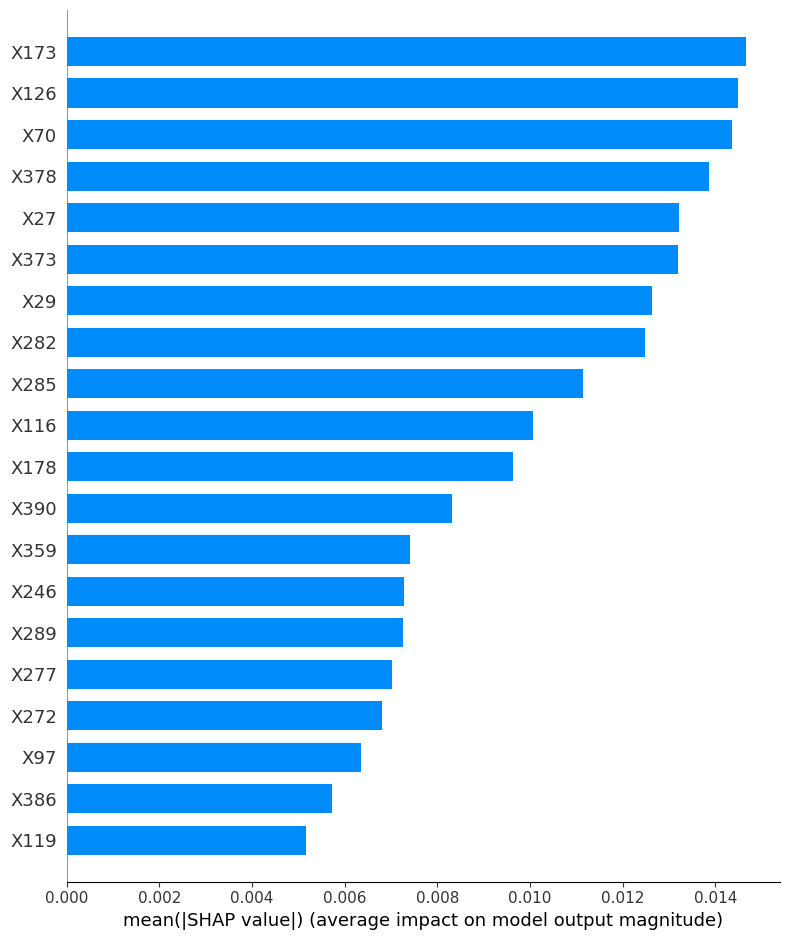

In [38]:
shap.summary_plot(shap_values_cls[:, :, 0], X_train_cls, plot_type='bar')  # 클래스 -1 기준

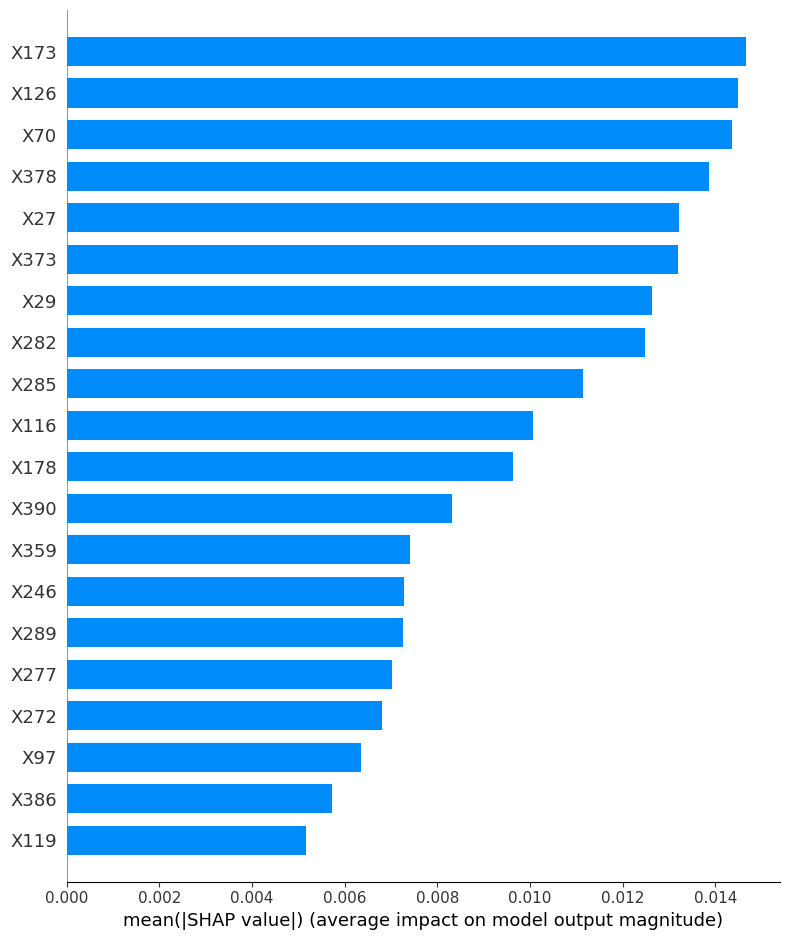

In [39]:
shap.summary_plot(shap_values_cls[:, :, 1], X_train_cls, plot_type='bar')  # 클래스 1 기준

#### Summary Plot (Scatter) - 클래스별

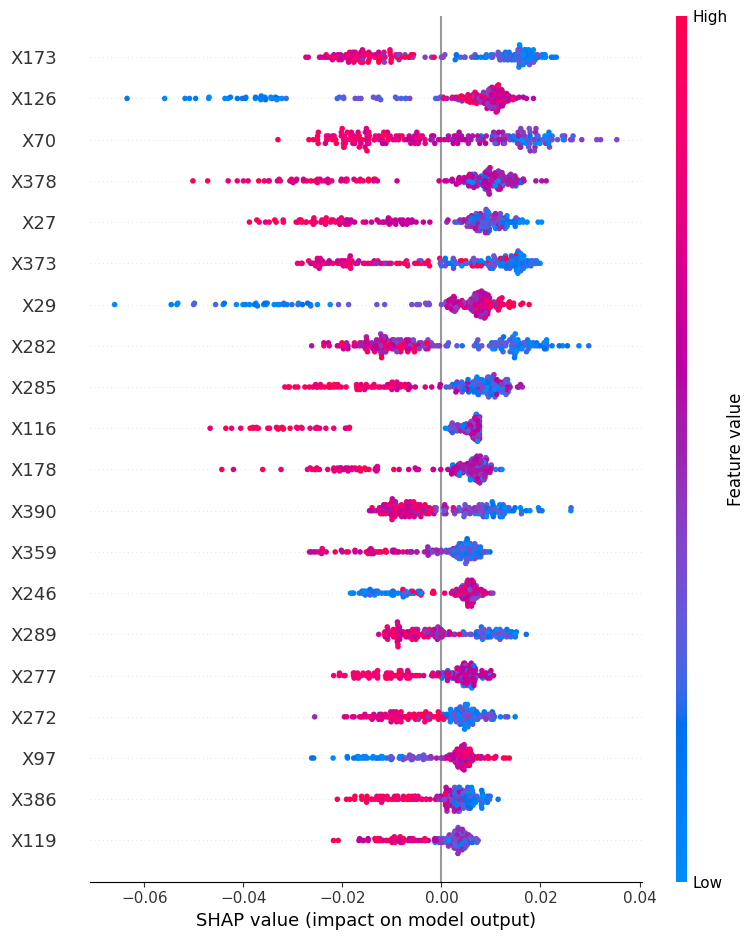

In [40]:
shap.summary_plot(shap_values_cls[:, :, 0], X_train_cls) # 클래스 = -1

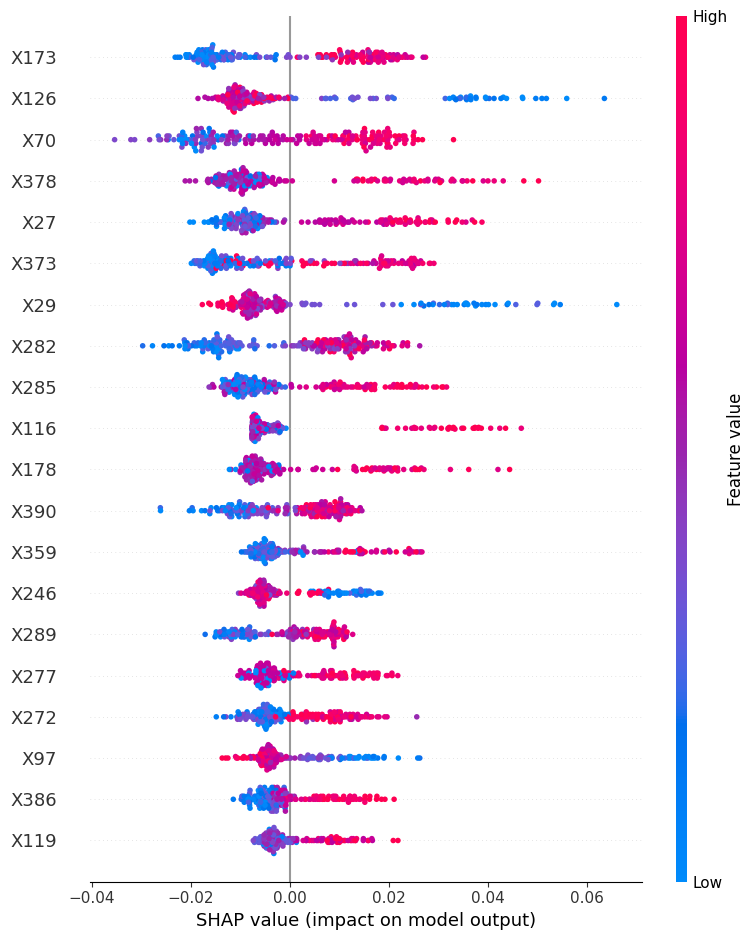

In [41]:
# 변수 중요도 순서는 같은데 부호가 반대 방향임

shap.summary_plot(shap_values_cls[:, :, 1], X_train_cls) # 클래스 = 1

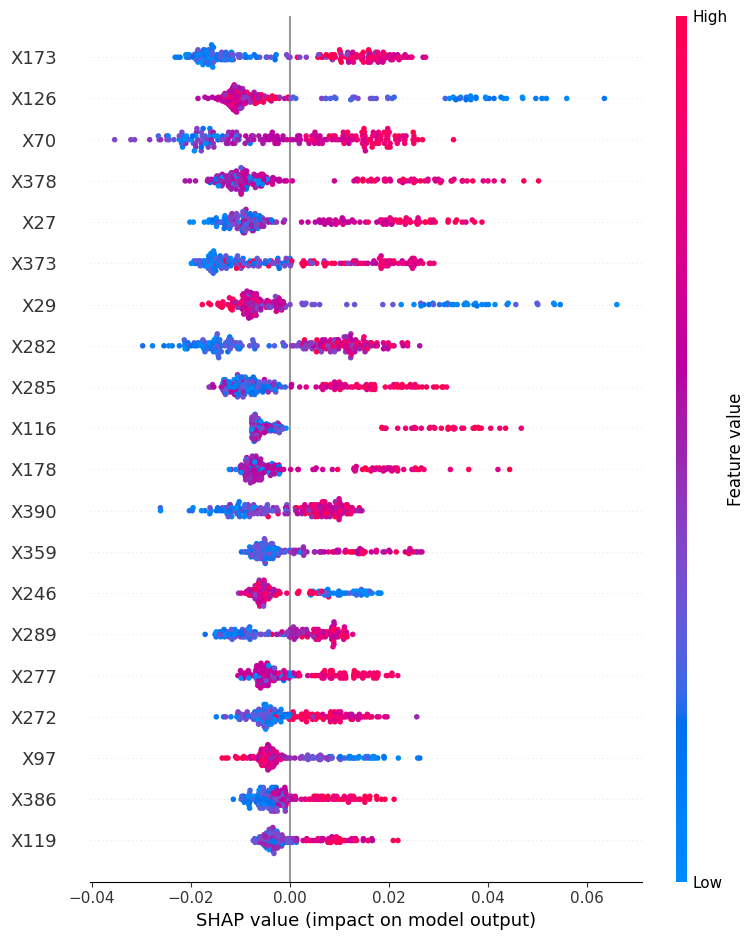

In [42]:
shap.summary_plot(shap_values_cls[:, :, 1], X_train_cls)

#### Force Plot (개별 데이터)

In [43]:
# 15번 데이터의 실제(정답) 클래스 확인
Y_train_cls.iloc[15]

np.int64(-1)

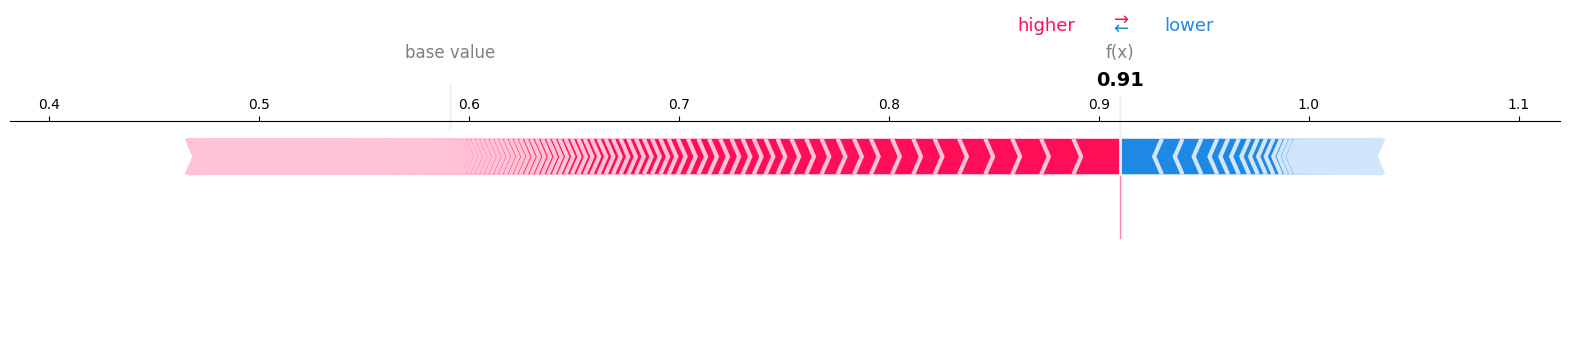

In [44]:
# 15번 데이터를 클래스 -1로 예측하는 데 각 feature가 어떻게 기여했는지 시각화

# expected_value[0]: 클래스 -1에 대한 기준값(base value)
# shap_values_cls[15, :, 0]: 15번 데이터의, 클래스 -1에 대한 각 feature별 SHAP value
# X_train_cls.iloc[15]: 15번 데이터의 실제 feature 값들 

shap.force_plot(
    explainer_cls.expected_value[0],
    shap_values_cls[15, :, 0],
    X_train_cls.iloc[15],
    matplotlib=True
)

위의 그래프 -> -1로 예상할 확률이 0.91

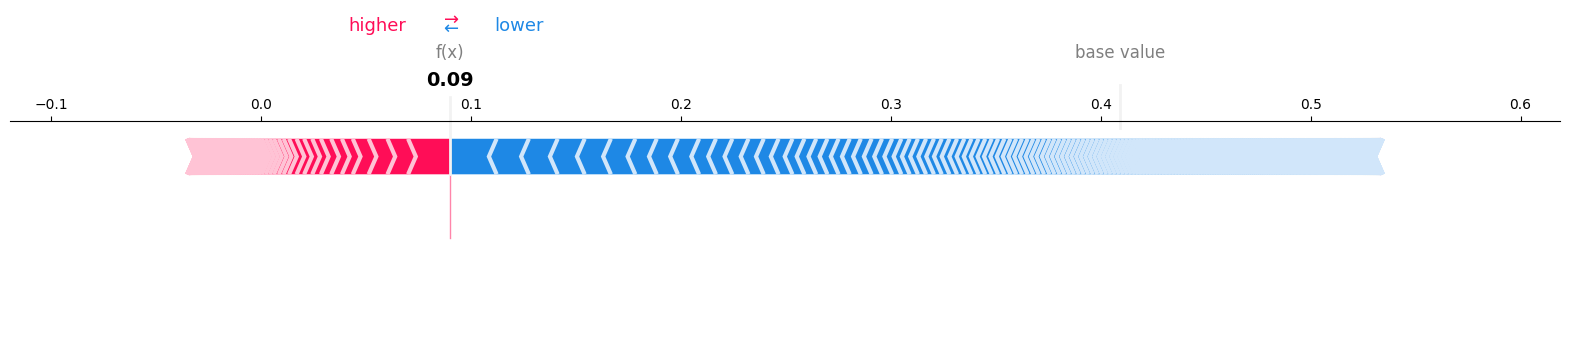

In [46]:
# 15번 데이터를 클래스 -1로 예측하는 데 각 feature가 어떻게 기여했는지 시각화

# expected_value[0]: 클래스 -1에 대한 기준값(base value)
# shap_values_cls[15, :, 0]: 15번 데이터의, 클래스 -1에 대한 각 feature별 SHAP value
# X_train_cls.iloc[15]: 15번 데이터의 실제 feature 값들 

shap.force_plot(
    explainer_cls.expected_value[1],
    shap_values_cls[15, :, 1],
    X_train_cls.iloc[15],
    matplotlib=True
)

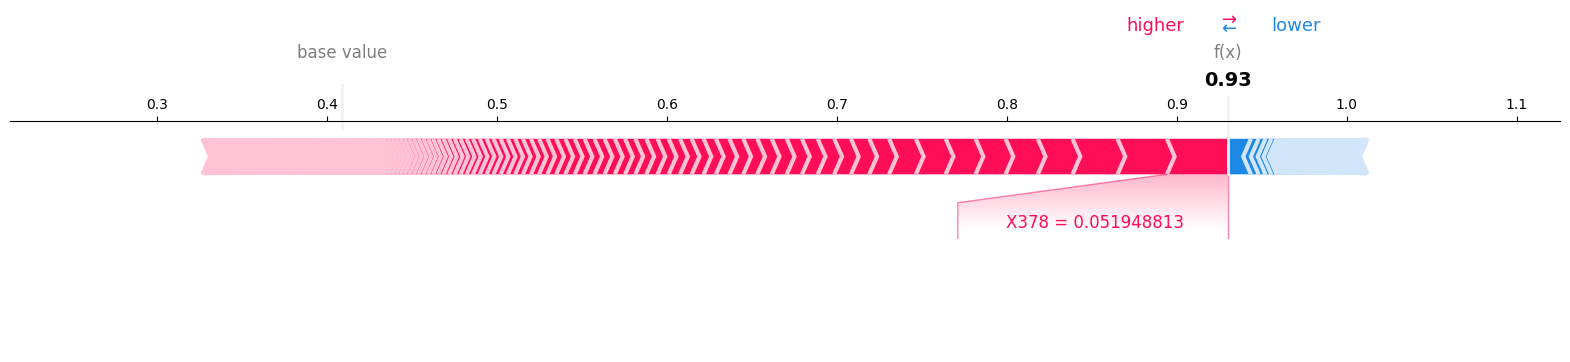

In [45]:
# 40번 데이터를 클래스 1로 예측하는 데 각 feature가 어떻게 기여했는지 시각화

# expected_value[1]: 클래스 1에 대한 기준값(base value)
# shap_values_cls[40, :, 1]: 40번 데이터의, 클래스 1에 대한 각 feature별 SHAP value
# X_train_cls.iloc[40]: 40번 데이터의 실제 feature 값들

shap.force_plot(
    explainer_cls.expected_value[1],
    shap_values_cls[40, :, 1],
    X_train_cls.iloc[40],
    matplotlib=True
)

#### Dependence Plot

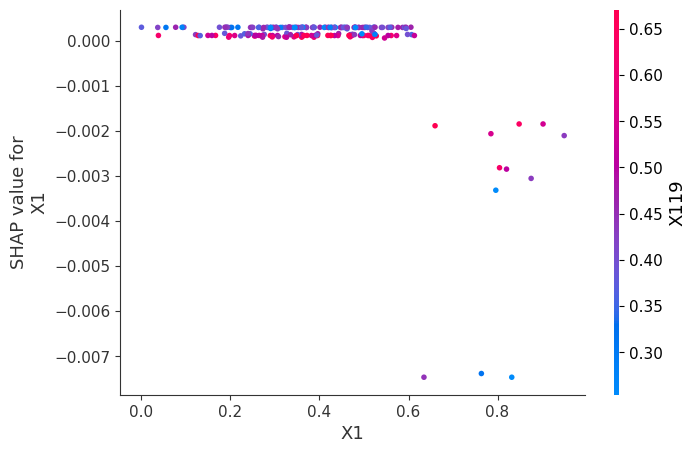

In [47]:
# "X1" feature 값에 따라, 클래스 -1에 대한 SHAP value가 어떻게 변하는지 시각화
# x축: X1의 실제 값, y축: X1의 클래스 -1 기준 SHAP value (예측에 미친 영향)
# 자동으로 X1과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X1",
    shap_values_cls[:, :, 0],
    X_train_cls
)

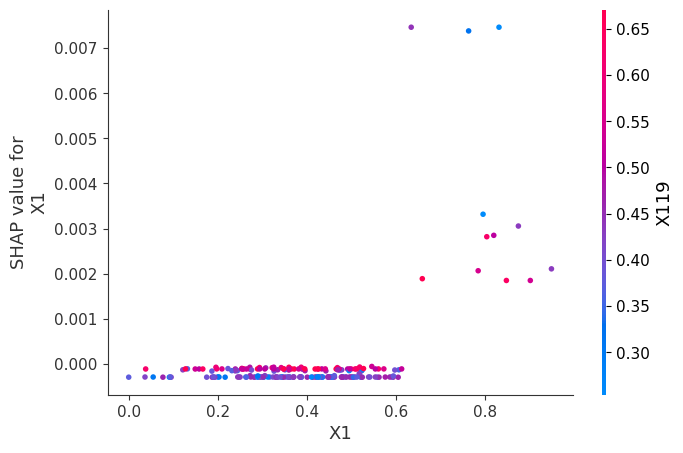

In [48]:
# "X1" feature 값에 따라, 클래스 1에 대한 SHAP value가 어떻게 변하는지 시각화
# x축: X1의 실제 값, y축: X1의 클래스 1 기준 SHAP value (예측에 미친 영향)
# 자동으로 X1과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X1",
    shap_values_cls[:, :, 1],
    X_train_cls
)

---

## 4) Vibe Coding 실습

**[과제 1]** 

지수는 Random Forest의 Feature Importance와 SHAP Value가 모두 변수의 중요도를 설명하는 방법이라는 것을 배웠습니다.

AI와 함께 Random Forest (회귀/분류)의 feature_importances_와 SHAP Summary Plot 결과를 비교해 보세요.

두 방법에서 중요하게 평가된 변수가 얼마나 비슷한지 확인하고 순위가 다른 변수는 왜 차이가 발생했는지 AI와 토의하여 해석해 보세요.

=== 회귀 Feature Importance (상위 15) ===


,feature,importance,rank_fi
0,X10,0.193025,1
1,X3,0.141376,2
2,X46,0.089514,3
3,X26,0.050647,4
4,X33,0.034804,5
5,X2,0.033480,6
6,X25,0.028282,7
7,X37,0.026450,8
8,X15,0.022193,9
9,X58,0.015704,10


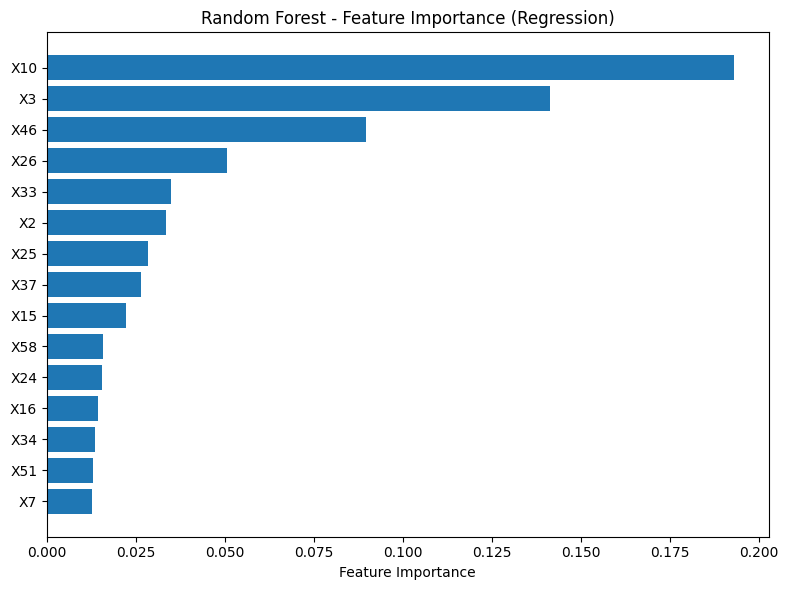

In [49]:
# ===== 1. Feature Importance (회귀) =====
fi_reg = pd.DataFrame({
    'feature': X_train_reg.columns,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

fi_reg['rank_fi'] = fi_reg.index + 1

print("=== 회귀 Feature Importance (상위 15) ===")
display(fi_reg.head(15))

# 막대 그래프
plt.figure(figsize=(8, 6))
top_n = 15
fi_top = fi_reg.head(top_n).iloc[::-1]
plt.barh(fi_top['feature'], fi_top['importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest - Feature Importance (Regression)')
plt.tight_layout()
plt.show()

=== 회귀 SHAP Importance (상위 15) ===


,feature,shap_importance,rank_shap
0,X10,0.879149,1
1,X3,0.640705,2
2,X46,0.516354,3
3,X26,0.273539,4
4,X33,0.226753,5
5,X2,0.181888,6
6,X25,0.146616,7
7,X37,0.127244,8
8,X15,0.124085,9
9,X16,0.100802,10


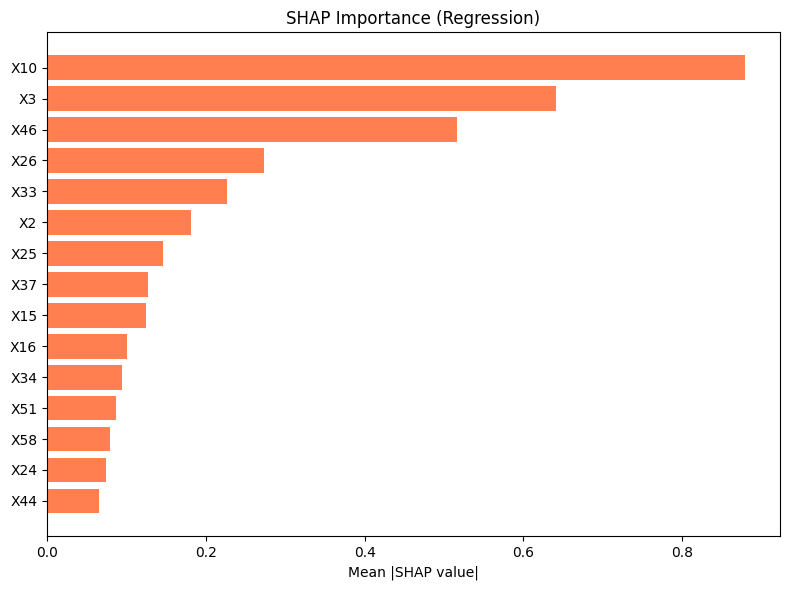

In [50]:
# ===== 2. SHAP Importance (회귀) =====
shap_imp_reg = np.abs(shap_values_reg).mean(axis=0)

shap_reg = pd.DataFrame({
    'feature': X_train_reg.columns,
    'shap_importance': shap_imp_reg
}).sort_values('shap_importance', ascending=False).reset_index(drop=True)

shap_reg['rank_shap'] = shap_reg.index + 1

print("=== 회귀 SHAP Importance (상위 15) ===")
display(shap_reg.head(15))

plt.figure(figsize=(8, 6))
shap_top = shap_reg.head(top_n).iloc[::-1]
plt.barh(shap_top['feature'], shap_top['shap_importance'], color='coral')
plt.xlabel('Mean |SHAP value|')
plt.title('SHAP Importance (Regression)')
plt.tight_layout()
plt.show()

In [51]:
fi_cls = pd.DataFrame({
    'feature': X_train_cls.columns,
    'importance': rf_cls.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

fi_cls['rank_fi'] = fi_cls.index + 1
display(fi_cls.head(15))

,feature,importance,rank_fi
0,X373,0.024285,1
1,X126,0.022421,2
2,X70,0.021257,3
3,X29,0.021031,4
4,X378,0.019221,5
5,X27,0.018447,6
6,X282,0.017265,7
7,X173,0.016975,8
8,X277,0.014767,9
9,X285,0.014313,10


In [53]:
shap_imp_cls = np.abs(shap_values_cls[:, :, 1]).mean(axis=0)  # 클래스 1

shap_cls = pd.DataFrame({
    'feature': X_train_cls.columns,
    'shap_importance': shap_imp_cls
}).sort_values('shap_importance', ascending=False).reset_index(drop=True)

shap_cls['rank_shap'] = shap_cls.index + 1
display(shap_cls.head(15))

,feature,shap_importance,rank_shap
0,X173,0.014662,1
1,X126,0.014494,2
2,X70,0.014354,3
3,X378,0.013869,4
4,X27,0.013207,5
5,X373,0.013201,6
6,X29,0.012635,7
7,X282,0.012474,8
8,X285,0.011140,9
9,X116,0.010060,10


In [56]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 기호 깨짐 방지

=== Feature Importance vs SHAP 비교 테이블 (회귀) ===


,feature,importance,rank_fi,shap_importance,rank_shap,fi_norm,shap_norm,rank_diff
0,X10,0.193025,1,0.879149,1,1.000000,1.000000,0
1,X3,0.141376,2,0.640705,2,0.732423,0.728779,0
2,X46,0.089514,3,0.516354,3,0.463741,0.587334,0
3,X26,0.050647,4,0.273539,4,0.262385,0.311141,0
4,X33,0.034804,5,0.226753,5,0.180309,0.257924,0
5,X2,0.033480,6,0.181888,6,0.173451,0.206891,0
6,X25,0.028282,7,0.146616,7,0.146517,0.166771,0
7,X37,0.026450,8,0.127244,8,0.137029,0.144735,0
8,X15,0.022193,9,0.124085,9,0.114976,0.141142,0
9,X58,0.015704,10,0.079550,13,0.081359,0.090485,3


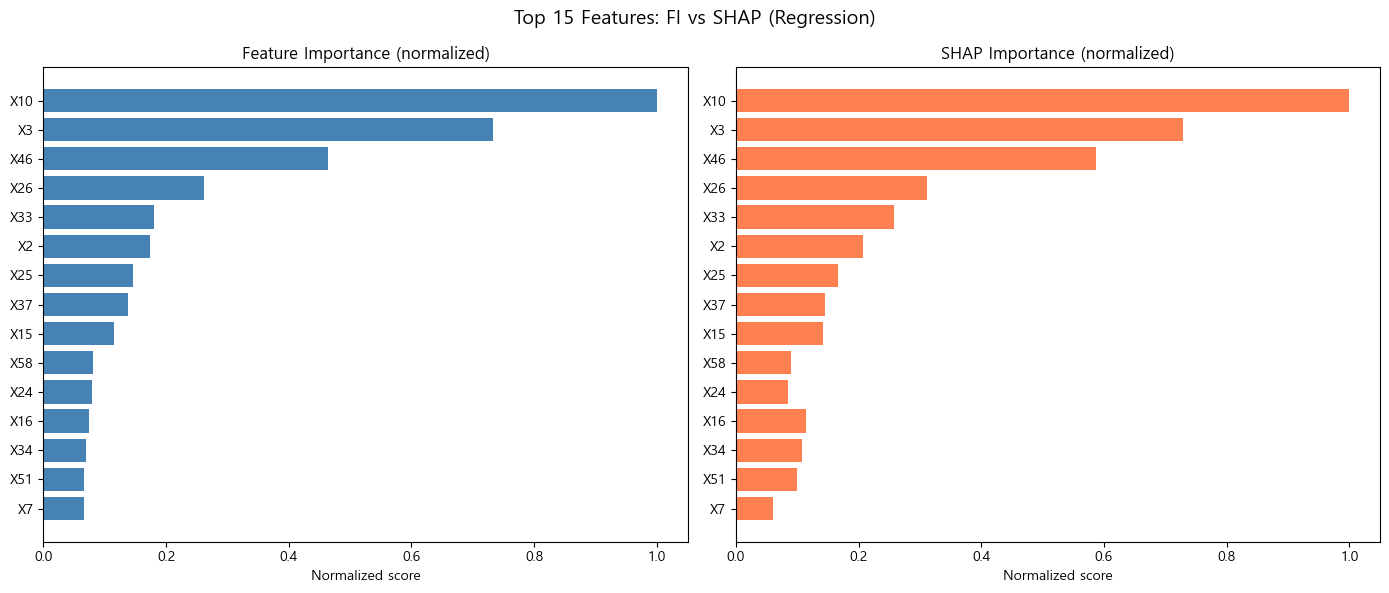

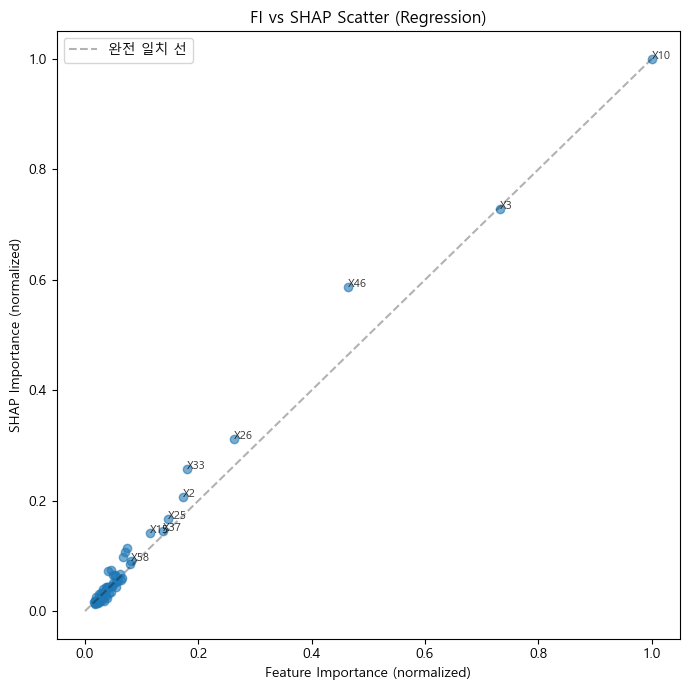

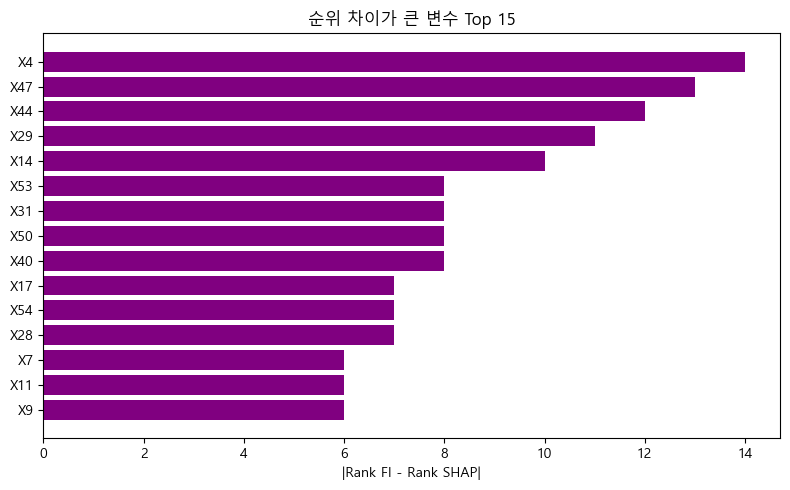

In [57]:
from scipy.stats import spearmanr

# ===== 3. 비교 테이블 (회귀) =====
compare_reg = fi_reg[['feature', 'importance', 'rank_fi']].merge(
    shap_reg[['feature', 'shap_importance', 'rank_shap']],
    on='feature'
)

# 0~1 정규화 (스케일 맞추기)
compare_reg['fi_norm'] = compare_reg['importance'] / compare_reg['importance'].max()
compare_reg['shap_norm'] = compare_reg['shap_importance'] / compare_reg['shap_importance'].max()
compare_reg['rank_diff'] = (compare_reg['rank_fi'] - compare_reg['rank_shap']).abs()

compare_reg = compare_reg.sort_values('rank_fi').reset_index(drop=True)

print("=== Feature Importance vs SHAP 비교 테이블 (회귀) ===")
display(compare_reg.head(20))

# --- 그래프 1: 나란히 막대 (상위 15) ---
top_features = compare_reg.head(top_n)['feature'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fi_plot = compare_reg.set_index('feature').loc[top_features, 'fi_norm'].iloc[::-1]
shap_plot = compare_reg.set_index('feature').loc[top_features, 'shap_norm'].iloc[::-1]

axes[0].barh(fi_plot.index, fi_plot.values, color='steelblue')
axes[0].set_title('Feature Importance (normalized)')
axes[0].set_xlabel('Normalized score')

axes[1].barh(shap_plot.index, shap_plot.values, color='coral')
axes[1].set_title('SHAP Importance (normalized)')
axes[1].set_xlabel('Normalized score')

plt.suptitle('Top 15 Features: FI vs SHAP (Regression)', fontsize=14)
plt.tight_layout()
plt.show()

# --- 그래프 2: 산점도 (순위/크기 관계) ---
plt.figure(figsize=(7, 7))
plt.scatter(compare_reg['fi_norm'], compare_reg['shap_norm'], alpha=0.6)

for _, row in compare_reg.head(10).iterrows():
    plt.annotate(row['feature'], (row['fi_norm'], row['shap_norm']),
                 fontsize=8, alpha=0.8)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='완전 일치 선')
plt.xlabel('Feature Importance (normalized)')
plt.ylabel('SHAP Importance (normalized)')
plt.title('FI vs SHAP Scatter (Regression)')
plt.legend()
plt.tight_layout()
plt.show()

# --- 그래프 3: 순위 차이 막대 ---
rank_diff_top = compare_reg.nlargest(15, 'rank_diff')
plt.figure(figsize=(8, 5))
plt.barh(rank_diff_top['feature'].iloc[::-1], rank_diff_top['rank_diff'].iloc[::-1], color='purple')
plt.xlabel('|Rank FI - Rank SHAP|')
plt.title('순위 차이가 큰 변수 Top 15')
plt.tight_layout()
plt.show()

In [58]:
compare_cls = fi_cls[['feature', 'importance', 'rank_fi']].merge(
    shap_cls[['feature', 'shap_importance', 'rank_shap']], on='feature'
)
compare_cls['rank_diff'] = (compare_cls['rank_fi'] - compare_cls['rank_shap']).abs()
rho_cls, _ = spearmanr(compare_cls['rank_fi'], compare_cls['rank_shap'])
print(f"[분류] Spearman: {rho_cls:.3f}")
display(compare_cls.sort_values('rank_diff', ascending=False).head(10))

[분류] Spearman: 0.963


,feature,importance,rank_fi,shap_importance,rank_shap,rank_diff
398,X396,0.000338,399,0.000680,228,171
144,X181,0.001941,145,0.000438,305,160
310,X47,0.000778,311,0.000967,157,154
126,X194,0.002111,127,0.000548,265,138
293,X233,0.000864,294,0.000897,172,122
163,X433,0.001735,164,0.000530,270,106
205,X118,0.001403,206,0.001523,102,104
197,X99,0.001489,198,0.000447,302,104
344,X58,0.000605,345,0.000625,241,104
226,X227,0.001282,227,0.001203,124,103


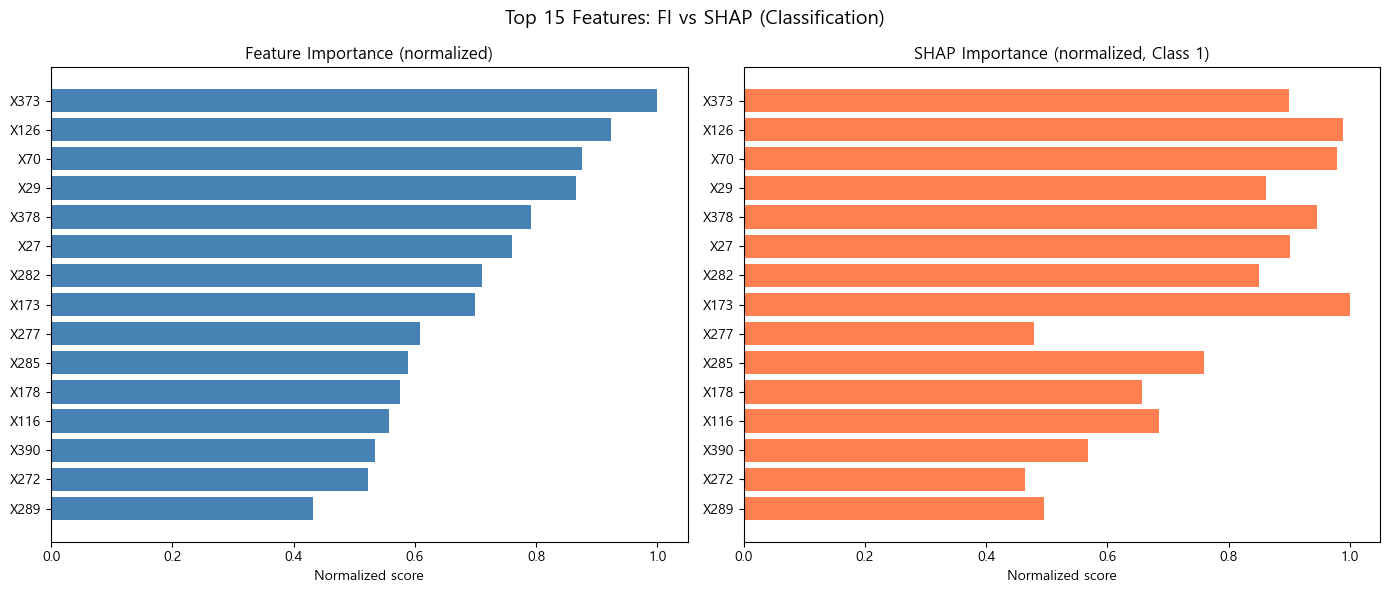

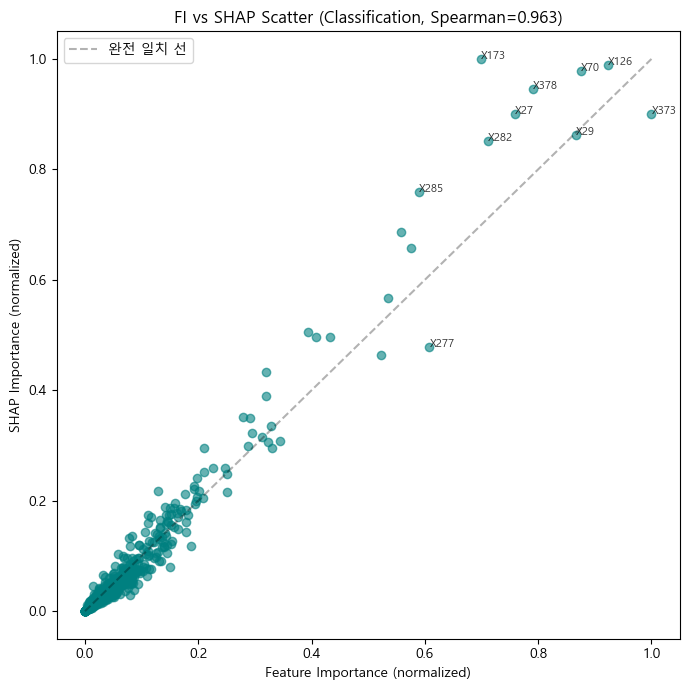

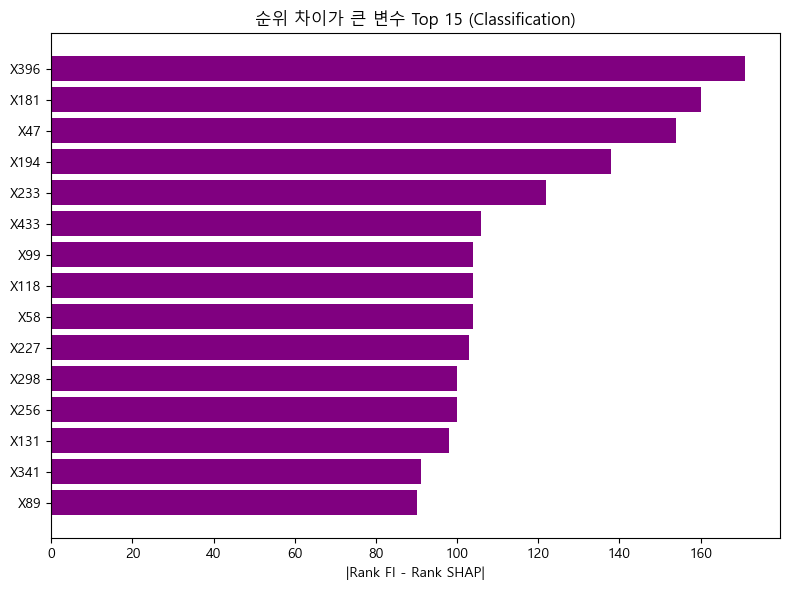

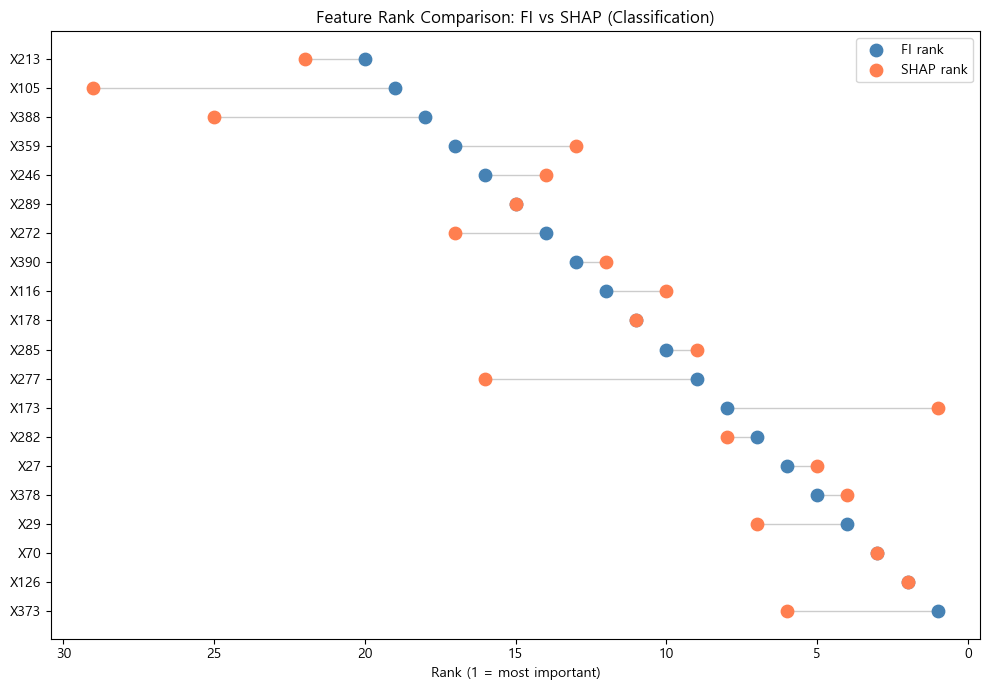

In [59]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 (경고 방지)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

top_n = 15

# 정규화 컬럼 추가 (없으면)
if 'fi_norm' not in compare_cls.columns:
    compare_cls['fi_norm'] = compare_cls['importance'] / compare_cls['importance'].max()
    compare_cls['shap_norm'] = compare_cls['shap_importance'] / compare_cls['shap_importance'].max()

top_features = compare_cls.sort_values('rank_fi').head(top_n)['feature'].tolist()

# ===== 그래프 1: FI vs SHAP 나란히 막대 (상위 15) =====
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fi_plot = compare_cls.set_index('feature').loc[top_features, 'fi_norm'].iloc[::-1]
shap_plot = compare_cls.set_index('feature').loc[top_features, 'shap_norm'].iloc[::-1]

axes[0].barh(fi_plot.index, fi_plot.values, color='steelblue')
axes[0].set_title('Feature Importance (normalized)')
axes[0].set_xlabel('Normalized score')

axes[1].barh(shap_plot.index, shap_plot.values, color='coral')
axes[1].set_title('SHAP Importance (normalized, Class 1)')
axes[1].set_xlabel('Normalized score')

plt.suptitle('Top 15 Features: FI vs SHAP (Classification)', fontsize=14)
plt.tight_layout()
plt.show()

# ===== 그래프 2: 산점도 (두 중요도 관계) =====
plt.figure(figsize=(7, 7))
plt.scatter(compare_cls['fi_norm'], compare_cls['shap_norm'], alpha=0.6, color='teal')

for _, row in compare_cls.head(10).iterrows():
    plt.annotate(row['feature'], (row['fi_norm'], row['shap_norm']),
                 fontsize=8, alpha=0.8)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='완전 일치 선')
plt.xlabel('Feature Importance (normalized)')
plt.ylabel('SHAP Importance (normalized)')
plt.title(f'FI vs SHAP Scatter (Classification, Spearman={rho_cls:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

# ===== 그래프 3: 순위 차이 큰 변수 =====
rank_diff_top = compare_cls.nlargest(top_n, 'rank_diff')

plt.figure(figsize=(8, 6))
plt.barh(rank_diff_top['feature'].iloc[::-1],
         rank_diff_top['rank_diff'].iloc[::-1],
         color='purple')
plt.xlabel('|Rank FI - Rank SHAP|')
plt.title('순위 차이가 큰 변수 Top 15 (Classification)')
plt.tight_layout()
plt.show()

# ===== 그래프 4: 순위 직접 비교 (dot plot) =====
top20 = compare_cls.sort_values('rank_fi').head(20)

plt.figure(figsize=(10, 7))
y_pos = np.arange(len(top20))

plt.scatter(top20['rank_fi'], y_pos, color='steelblue', s=80, label='FI rank', zorder=3)
plt.scatter(top20['rank_shap'], y_pos, color='coral', s=80, label='SHAP rank', zorder=3)

for i, (_, row) in enumerate(top20.iterrows()):
    plt.plot([row['rank_fi'], row['rank_shap']], [i, i],
             color='gray', alpha=0.4, linewidth=1)

plt.yticks(y_pos, top20['feature'])
plt.xlabel('Rank (1 = most important)')
plt.title('Feature Rank Comparison: FI vs SHAP (Classification)')
plt.legend()
plt.gca().invert_xaxis()  # 1위가 오른쪽
plt.tight_layout()
plt.show()